# **Project 2 - Meteorites: Smaller Than We Thought?**

## Dean Xoubi

# **1. Introduction**

In [2]:
#Imports here
import pandas as pd
df = pd.read_csv("meteorlandingscsv.csv")


### **Data Set Introduction:**

We retrieved this dataset from Kaggle.com, and the **link** to the dataset is: **https://www.kaggle.com/datasets/nasa/meteorite-landings**

This dataset includes all the meteorite landings from **NASA's Meteoritical Society**. The available data would be considered a full population, given that this dataset is frequently updated to include new findings that NASA's Meteoritical Society discovers in regards to meteorite landings. Within this dataset, NASA has compiled key information about each meteorite landing, making it the dataset's unit of observation. Some of this information includes the name of the meteorite, the weight (in grams), the geolocation of the discovered meteorite, the year it was discovered, and a unique numerical ID for each meteorite.

The raw dataset (without cleaning) consists of **45716 observations**, and has **10 columns**.

### **Populations and Samples:**

I would say our dataset represents a population, given that the dataset is described on Kaggle as being directly downloaded from **NASA's Data Portal**, meaning that every occurence of observation of a meteorite landing that **NASA's Meteoritical Society** has discovered is within our dataset, effectively making it a population.

The population of interest would be **all meteorite landings**. Since our dataset is a population, our analysis for this project will focus on taking a large sample, and finding residuals based on the population info we have at hand. The reference to this sample will be called **"dfsample"**.

### **Research Questions:**

For **section 2**, the research questions we will answer are:
 - **What is the proportion of meteorites in our current data whose masses are over 1000 grams.**
 - **With 85% confidence, what is a reasonable interval of the proportion of meteorites whose masses are over 1000 grams for our population.**

For **section 3**, the research questions we will answer are:
 - **What are summary measures for the mass of meteorites in our data sample.**
 - **Is the median weight of all meteorites (population) less than 1000 grams?**

### **Contextual Importance: Why Are We Trying to Figure This Stuff Out?**

The answers to these research questions could yield very interesting results. For example, during our previous data analysis in which we analyzed the frequency of meteorite landings in relation to the year, we saw that in recent decades, there have been an astronomical (literally) increase in meteorite landings. This gave us concrete evidence to conclude that the year does in-fact affect the frequency of meteorite landings. However, when really delving into this dataset, we discovered that the weight variable was in grams, meaning that even the heaviest meteorites recorded in the previous years were not nearly as heavy as we presumed, so we thought we should focus our efforts on analyzing this variable. That is why we decided to test certain theories with out hypothesis test, and come up with a confidence interval for the proportion of somewhat heavy meteorites.

The result of this analysis could communicate to us accurate predictions about population parameters like the median mass of a meteorite, and proportion of the meteorites that are above or below a certain threshold, which can give us a true perspective on the grounded and scientific population of meteorites around the world.

Furthermore, researchers can use information like this to really see how unusual the mass of a modern meteorite is compared to the findings of our analysis. For example, pop culture might have conditioned us to presume that a 100 kg is normal for a meteorite's mass, but our analysis might tell a different story. All in all, this information could be really useful in providing us based thresholds on the masses of meteorites, so scientists and astronomers can determine how serious a meteorite is based on its mass.

# **2. Confidence Interval Analytical Tasks**

###  **Our research questions for this section:**
 - What is the proportion of meteorites in our current data that are over 1000g in weight.
 - With 85% confidence, what is a reasonable interval of this proportion of this variable in our population.


In [3]:
dfclean = df.dropna()
dfclean = dfclean[dfclean["year"] < 2026]
#Cleaning the data includes dropping observations with missing values, making sure the year is valid.
#Old length of data frame: 45716
#New length of data frame: 38115
dfclean.shape

dfclean["mass"].dropna() #type is float, so no values of object, after dropping na, we still have 38115 observations.
dfclean["over 1000g"] = dfclean["mass"] > 1000 #Creating logical variable out of quantitative variable


dfsample = dfclean.sample(n = 200) #Creating random sample to use for analysis so we are not just using population data.
dfsample["mass"].describe()

len(dfsample[dfsample["over 1000g"] == True]) / len(dfsample)


0.155

The answer to our first research question is **.155**, which is the proportion of meteorites in our sample that have a mass greater than 1000 grams.

### **Descriptive Analysis**

The sample size we will use for this analysis will be 200 observations or meteorite landings from our original dataset. After using the .describe method on our variable of interest, we see that the mean mass of meteorites in our sample is 2283 grams, and the median is 30 grams, so it is safe to conclude that there are **VERY LARGE** outliers. This is also apparent by the extreme difference between our max value and our 75th quartile value. In general terms, there might have been a couple meteorites with extremely heavy masses among the larger set of meteorites which greatly skews the mean.

### **Creating Confidence Interval**

Let us identify our confidence level and parameter of interest!

 - The confidence level we will choose is 85%.
 - Our parameter of interest is the proportion of meteorites that have a mass greater than 1000 grams. 

In [4]:
sampling_dist = []
for i in range(1000):
    sample = dfsample.sample(n = len(dfsample), replace = True)
    sampling_dist.append((sample["over 1000g"] == True).mean()) #calculates proportion of meteorites with weight above 1000g.
sampling_statistics = pd.DataFrame(sampling_dist)
sampling_statistics

,0
0,0.105
1,0.185
2,0.145
3,0.140
4,0.150
...,...
995,0.190
996,0.155
997,0.200
998,0.155


In [5]:
lowerbound = sampling_statistics.quantile(.075) #lower bound of confidence interval
upperbound = sampling_statistics.quantile(.925) #upper bound of confidence interval

print(f"Our 85% confidence interval for the population proportion of meteorites that are heavier than 1000 grams is [{lowerbound[0]} , {upperbound[0]}]")


Our 85% confidence interval for the population proportion of meteorites that are heavier than 1000 grams is [0.115 , 0.19]


#### **Confidence Interval Results: Our 85% confidence interval for the population proportion of meteorites that are heavier than 1000 grams is [0.115 , 0.19]**

### **Confidence Level Interpretation**

 - We are 85% confident that the true population proportion of all meteorites whose masses are greater than 1000 grams is contained within the interval [.115, .19] Thus, we would say that the following interval is a reasonable interval in which our population proportion lies.

# **3. Hypothesis Testing Analytical Tasks**

### **Our Research Questions for this Section:**

 - What are the summary measures of the mass of meteorites in our sample.
 - Is our theory true that the average mass of the population of all meteorites is less than 1000 grams.

In [6]:
dfclean["mass"]
dfclean["mass"].dtypes
dfclean["mass"].dropna() #After dropping na, the length of the column is still the same, meaning there were no null values to clean

dfsample["mass"].describe() #It looks like these are our summary statistics of our sample.

count       200.000000
mean       5413.341085
std       50235.413637
min           0.260000
25%           6.780000
50%          33.145000
75%         308.062500
max      700000.000000
Name: mass, dtype: float64

### **Summary Measures of our Variable (Meteorite mass (g))**

It looks like some summary measures of our variable include some important **measures of center and spread**. For example, we see that according to our .describe table, the mean of the variable in our sample is 5413 grams, and the median is 33.15, so obvious evidence of outliers. We also see that the max and min of the variable are as extreme as you can get, and the standard deviation is extremely high, at 50235.41. 

<Axes: >

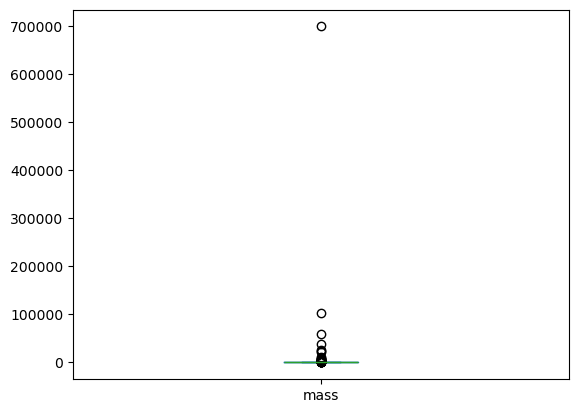

In [7]:
dfsample["mass"].plot.box()

### **Analysis Results**

As you can see by our summary statistics and our box plot, outliers **SEVERELY** affect the distribution of this quantitative variable, meaning that it's probably not the smartest thing to let the mean represent our quantitative variable. The high outliers in our data would skew the results massively. When the graph is skewed or outliers transform the mean, it is probably safest to describe our data with the **median rather than the mean**, according to the obvious outliers in the box plot, and the extreme difference between the 75th quartile and the variable's max value.

### **Performing Hypothesis Test**

Our hypothesis is that the median mass of all meteorites that land on Earth is below 1000 grams.
 - **Parameter of interest**: Median mass of all meteorites (in grams)

 - **Null Hypothesis**: Median mass of all meteorites is equal to 1000 grams
 - **Alternative Hypothesis**: Median mass of all meteorites is less than 1000 grams
 
 - **Significance Level: 5% / .05**

In [ ]:
samplemedian = dfsample["mass"].median()
samplemedian
#Storing our sample median in a variable


dfsample["skeptic"] = dfsample["mass"] - samplemedian + 1000
dfsample["skeptic"].describe()
#making our skeptic column which assumes that the null hypothesis is true



sampling_dist = []
for i in range(1000):
   sample = dfsample.sample(len(dfsample), replace = True)
   sampling_dist.append(sample["skeptic"].median())
sampling_statistics = pd.DataFrame(sampling_dist)

sampling_statistics[0].describe()
#We now have a sampling distribution that adopted the skeptic's claim.

count    1000.000000
mean     1001.477650
std        10.312654
min       982.710000
25%       995.245000
50%      1000.000000
75%      1002.155000
max      1059.555000
Name: 0, dtype: float64

In [11]:
pval = (sampling_statistics[0] < samplemedian).mean()
pval

#We now have our p-value for the hypothesis test

0.0

#### **Hypothesis Test Conclusion** - With a p-value of 0 percent, which is less than our significance level of 5 percent or .05, we have sufficient evidence to **REJECT** our null hypothesis, and suggest that our alternative hypothesis is true.

### **Reflecting on the results of our hypothesis test**

Well first, we noticed that we had gotten a p-value that was 0.0, meaning that there was EXTREMELY little to no probability of obtaining a sample median that was as extreme or more extreme than our null hypothesis, which was 1000 grams. Being that this was the first analysis we did on the mass of meteorites, we wanted the threshold to be a flat kilogram, which we thought was pretty reasonable given our perceptions on the sizes of meteorites.

But according to our hypothesis test, the p-value we got communicated a check which was definitely needed, that being how small our p-value was. This showed that we had reason to believe our alternative hypothesis was true, and that the median mass of all meteorites is **LESS** than 1000 grams.

## Any other type of analysis/question you want to explore with this dataset.

<u>Why?</u>: Sometimes undergraduate students will put the research projects that they did for their classes on their resumes when applying for graduate schools, internships, and jobs. If you're interested in showcasing cool analyses to write on your resume, this section could help with that. **(This section is not worth any points though).**

#### **What countries' meteorite landings have the largest meteorites? What countries have the most frequent occurrences of meteorite landings?**

#### **What is the smallest and largest meteorite that has landed in the United States?**

#### **Does industrialization affect meteorite landing frequency? Do more industrialized counties experience more meteorite landings?**

# **4. Conclusion**

### **A Needed Recap**


For this part of the project, we decided to focus mainly on one variable, and that was **the meteorite's mass**. Given that our data gave us each meteorite as a unit of observation, then among the variables that were provided to us through **NASA's dataset**, mass was a very easy variable to analyze, and it yielded important results in our opinion, given that we see mass as important, if not more important, as the year a meteorite landed or its geolocation.

### **Confidence Interval Restated**

Our confidence interval gave us an interval of the proportion of meteorites in the population OF ALL meteorites on Earth that have a mass that is greater than 1 kilogram, which was between .115 and .19. This, even to me, was extremely surprising, given that people would think that meteorites are some hulking chunks of rocks hurling towards Earth's atmosphere, but our data tells us otherwise. Our data tells us, with 85 percent confidence of course, that you could expect a heavy meteorite (above 1 kg) **only** 10-20% of the time. 

### **Hypothesis Test Restated**

Our hypothesis test allowed us to test two opposing theories, one being that the median mass of all meteorites is 1 kg, or the median mass is below 1 kg. According to the p-value that we got, we were able to reject the theory that the median was 1 kg, and we had reason to believe the median mass of all meteorites **was much lower**. 

### **Limitations and Important Things We Noted**

There really weren't many limitations when analyzing our data. One that we can think of was that there was not already a logical variable to analyze, but we were able to create one and implement it into our data frame. Some contextual information that was important was what mass we chose for our hypothesis test threshold. Initially, we were going to choose an astronomical number, given that our prior perception told us meteorites were **VERY** heavy, but with some outside research and sifting through our data frame, we thought 1 kg was an appropriate and  effective threshold. If someone else, like someone we described in the introduction used the results of our p-test on an obvious test like testing the theory if the median mass would be over or under, say, 1000 kg, it wouldn't really give them much to work with, but 1 kg gives a good basis to conceptualize and benefit from results.

### **What Can We Use These Analyses For?**

Some research questions or analyses that might stem from our analyses in this part of the project, might delve into other parameters for this variable. Perhaps copy our formula and change the threshold for our null hypothesis and see what results you get. Or maybe remove all the outliers from the data and analyze the mean mass, or measures of spread even. We think a robust quantitative variable that can communicate a lot of information like the mass of a meteorite is a good starting point for analysis, and opens the gates to future analyses!